# 05 Forecasting Baseline

Notebook nay dung 4 baseline time-series model de tao moc so sanh cho feature engineering.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'dataset').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root from the current working directory.')

PROJECT_ROOT = find_project_root(Path.cwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.competition_workflow import build_modeling_dataset, export_baseline_artifacts, run_baseline_models

pd.set_option('display.max_columns', None)

In [2]:
baseline_frame = build_modeling_dataset(PROJECT_ROOT)[['date', 'Revenue']].dropna().copy()
baseline_frame = baseline_frame.sort_values('date').reset_index(drop=True)
date_range = pd.date_range(baseline_frame['date'].min(), baseline_frame['date'].max(), freq='D')
missing_dates = date_range.difference(baseline_frame['date'])
display(baseline_frame.head())
print(f'Missing dates in target series: {len(missing_dates)}')

,date,Revenue
0,2012-07-04,5123547.94
1,2012-07-05,2751773.45
2,2012-07-06,3054029.42
3,2012-07-07,2667930.94
4,2012-07-08,2360851.90


Missing dates in target series: 0


In [3]:
baseline_scores, baseline_predictions = run_baseline_models(PROJECT_ROOT, target_col='Revenue')
display(baseline_scores)
display(baseline_predictions.tail())

,Model,MAE,RMSE,R2,ScoredRows
0,Naive,6.695925e+05,1.020221e+06,0.626401,767
2,Moving Average (7),8.720616e+05,1.306300e+06,0.387504,767
3,Linear Regression,1.341432e+06,1.703663e+06,-0.041801,767
1,Seasonal Naive,1.219872e+06,1.788122e+06,-0.147655,767


,date,Revenue,time_index,month,dayofweek,naive_pred,seasonal_naive_pred,moving_average_pred,linear_regression_pred
762,2022-12-27,2100553.66,3828,12,1,2110830.12,2026810.08,1.679073e+06,2.692358e+06
763,2022-12-28,3448729.20,3829,12,2,2100553.66,1795395.02,1.689608e+06,2.596738e+06
764,2022-12-29,3083944.33,3830,12,3,3448729.20,1791622.46,1.925798e+06,2.501119e+06
765,2022-12-30,2884668.76,3831,12,4,3083944.33,1501209.11,2.110416e+06,2.405500e+06
766,2022-12-31,2383037.48,3832,12,5,2884668.76,1390870.89,2.308053e+06,2.309880e+06


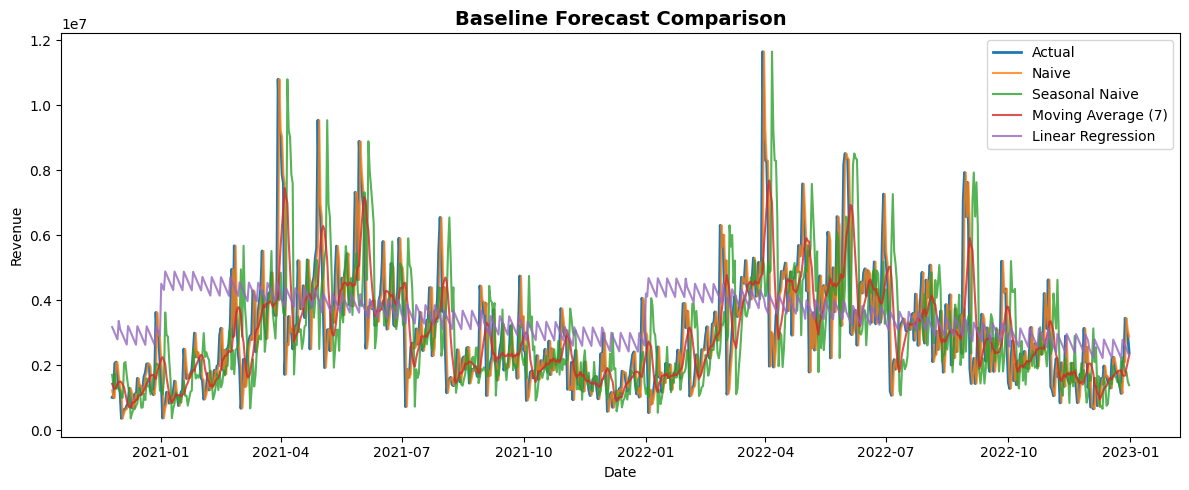

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(baseline_predictions['date'], baseline_predictions['Revenue'], label='Actual', linewidth=2)
for column, label in [
    ('naive_pred', 'Naive'),
    ('seasonal_naive_pred', 'Seasonal Naive'),
    ('moving_average_pred', 'Moving Average (7)'),
    ('linear_regression_pred', 'Linear Regression'),
]:
    ax.plot(baseline_predictions['date'], baseline_predictions[column], label=label, alpha=0.8)
ax.set_title('Baseline Forecast Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
artifact_paths = export_baseline_artifacts(PROJECT_ROOT, target_col='Revenue')
pd.DataFrame({
    'artifact': list(artifact_paths.keys()),
    'path': [str(path.relative_to(PROJECT_ROOT)) for path in artifact_paths.values()],
}).sort_values('artifact')

,artifact,path
2,baseline_forecast_plot,charts\baseline_forecast.png
1,baseline_predictions,artifacts\forecast_baseline\baseline_predictio...
0,baseline_scores,artifacts\forecast_baseline\baseline_scores.csv
